In [1]:
from typing import TypedDict, Dict, Any 
from langchain_openrouter import ChatOpenRouter
from langgraph.graph import StateGraph

In [2]:
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
llm = ChatOpenRouter(            #llm conf
    model="gpt-4o-mini",
    temperature=0
)

In [4]:
class PatentState(TypedDict):    #state of the graph
    file_path : str
    raw_data: Dict[str, Any]
    summary: str

In [5]:
import json
def load_and_filter_patent_data(file_path: str) -> str:
    """
    Loads a patent JSON file (list of 3 API responses),
    strips fields the LLM doesn't need
    """
    with open(file_path, "r", encoding="utf-8") as f:
        raw = json.load(f)

    api1 = raw[0]["response"]
    api2 = raw[1]["response"]
    api3 = raw[2]["response"]

    #campaign defandants                                                                        
    filtered_campaigns = [
        {
            "campaign_name":        entry["campaign_name"],
            "defendant_started":    entry["defendant_started"],
            "jurisdiction":         entry["jurisdiction"],
            "defendants": [
                {"name": d["defendant_parent_name"]}
                for d in entry["defendants"]
            ]
        }
        for entry in api1["campaign_defendants"]
    ]

    #Assignment graph 
    filtered_graph = []
    for graph in api1["transactional_assignments"]:
        filtered_graph.append({
            "nodes": [
                {
                    "name":         node["name"],
                    "type":         node["type"],
                    "display_date": node["display_date"],
                }
                for node in graph["nodes"]
            ],
            "links": [
                {
                    "source_node":  link["source_node"],
                    "target_node":  link["target_node"],
                    "asset_count":  link["asset_count"],
                }
                for link in graph["links"]
            ]
        })

    # Assignment details 
    filtered_assignments = [
        {
            "executed_date":    a["executed_date"],
            "recorded_date":    a["recorded_date"],
            "assignor":         [x["name"] for x in a["assignor_details"]],
            "assignee":         [x["name"] for x in a["assignee_details"]],
            "assignee_address": a["assignee_details"][0].get("assignee_address", ""),
            "conveyance_type":  a["conveyance_type"],
            "assignment_type":  a["assignment_type"],
            "property_count":   a["property_count"],
            "correspondents":   a["correspondents"],
            "related_campaign": [
                {
                    "campaign_name":       c["campaign_name"],
                    "campaign_start_date": c["camaign_start_date"],
                    "campaign_closed_date":c["campaign_closed_date"],
                }
                for c in a["related_campaigns"]
            ]
        }
        for a in api2
    ]

    # patent_portfolio
    filtered_patents = [
        {
            "patnum":        p["patnum"],
            "title":         p["title"],
            "priority_date": p["priority_date"],
            "is_sep":        p["is_seps_tag"],
        }
        for p in api3["patents"]
    ]

    filtered_portfolio = {
        "property_count":    api3["property_count"],
        "patent_count":      api3["patent_count"],
        "application_count": api3["application_count"],
        "patents":           filtered_patents,
    }

    # merge
    filtered = {
        "campaign_defendants":       filtered_campaigns,
        "transactional_assignments": filtered_graph,
        "assignment_details":        filtered_assignments,
        "patent_portfolio":          filtered_portfolio,
    }

    return json.dumps(filtered, indent=2)



In [6]:
import json

def collect_data(state: PatentState) -> PatentState:
    
    file_path = state["file_path"]  

    content = load_and_filter_patent_data(file_path)
    #with open(file_path, "r", encoding="utf-8") as f:
        #content = json.load(f)

    return {
        **state,
        "raw_data": content
    }

In [7]:
def build_summary_prompt(data):
    import json

    return f"""
You are a senior patent litigation attorney with over 10 years of experience in patent enforcement, licensing, and litigation strategy.

Your task is to analyze structured patent, assignment, and litigation campaign data and produce a professional-grade legal summary.

Write in a precise, analytical, and concise style similar to internal legal memos. Avoid generic explanations.

Focus on legal and strategic insights.

---
WRITING STYLE:

- No fluff, no repetition
- No JSON output

---

DATA:
{json.dumps(data, indent=2)}
"""

In [8]:
def summarize_data(state: PatentState) -> PatentState:
    
    prompt = build_summary_prompt(state["raw_data"])
    
    response = llm.invoke(prompt)

    return {
        **state,
        "summary": response.content
    }

In [9]:
graph = StateGraph(PatentState)

graph.add_node("collect_data",collect_data)

graph.add_node("summarize_data",summarize_data)


graph.set_entry_point("collect_data")

graph.add_edge("collect_data","summarize_data")


graph.set_finish_point("summarize_data")

agent = graph.compile()



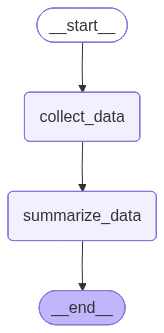

In [10]:
agent

In [11]:
result = agent.invoke({
    "file_path": r"C:\Users\kamalganth\Documents\RPX_Summarization_Agent\data\pat_5.json",
    "raw_data": {},
    "summary": ""
})

In [12]:
print(result["summary"])

**Legal Summary: Aire Technology Limited Patent Campaign Analysis**

**Campaign Overview:**
Aire Technology Limited (formerly Bowen Ventures Limited) has initiated a series of patent enforcement actions primarily targeting major technology companies, including Samsung Electronics Co. Ltd., Apple Inc., and Alphabet Inc. The campaign revolves around U.S. Patent No. 8,174,360, which pertains to a method for secure electronic transactions using portable data support. The campaign commenced on September 15, 2021, in the District of Columbia (DC) and has extended to the Patent Trial and Appeal Board (PTAB) for inter partes reviews.

**Defendant Engagement:**
1. **Defendants and Dates:**
   - Samsung Electronics Co. Ltd.: Engaged on September 15, 2021, and again on April 22, 2022.
   - Apple Inc.: Engaged on October 22, 2021, and subsequently on June 15 and October 21, 2022.
   - Alphabet Inc.: Engaged on October 25, 2021.

2. **Jurisdictional Strategy:**
   - The campaign has utilized both d